# HOUSE RENT PREDICTION USING KAGGLE DATASET (REGRESSION)

# House Rent Prediction

## Project Overview
This project builds a machine learning model that predicts house sale prices.
## Objectives
- Perform exploratory data analysis (EDA)
- Clean and preprocess the dataset
- Train multiple machine learning models
- Select the best performing model
- Deploy the model using Streamlit

## Target Variable
SalePrice

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import pickle


In [2]:
df_train = pd.read_csv("train.csv")
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
df_train.shape

(1460, 81)

In [5]:
df_train.isna().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [6]:
missing_percent=df_train.isna().mean()*100
missing_percent

Id                0.000000
MSSubClass        0.000000
MSZoning          0.000000
LotFrontage      17.739726
LotArea           0.000000
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 81, dtype: float64

In [7]:
missing_percent[missing_percent >0]

LotFrontage     17.739726
Alley           93.767123
MasVnrType      59.726027
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtFinType2     2.602740
Electrical       0.068493
FireplaceQu     47.260274
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
PoolQC          99.520548
Fence           80.753425
MiscFeature     96.301370
dtype: float64

In [8]:
cols_to_drop=missing_percent[missing_percent>30].index # .index is used to get the column name of columns dropped
cols_to_drop

Index(['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature'], dtype='object')

In [9]:
df_train.drop(columns=cols_to_drop, inplace=True)

In [10]:
#Confirming if columns with more than 30% missing values has been successfully dropped
missing_percent=df_train.isna().mean()*100
missing_percent[missing_percent>0]

LotFrontage     17.739726
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtFinType2     2.602740
Electrical       0.068493
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
dtype: float64

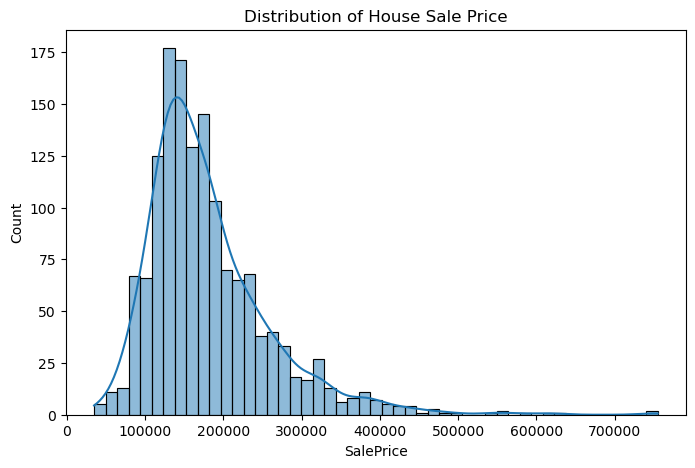

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df_train["SalePrice"], kde=True)
plt.title("Distribution of House Sale Price");

## Distribution of House Prices

The distribution of **SalePrice** is right-skewed.

This means:

- Most houses are sold at moderate prices
- A small number of houses have very high prices

For many machine learning algorithms, applying a **log transformation** to the target variable can improve model performance by reducing skewness.

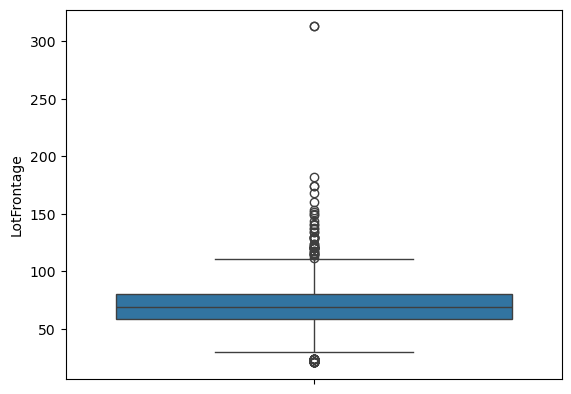

In [12]:
sns.boxplot(df_train["LotFrontage"])
plt.show()

In [13]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 75 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [14]:
numerical_cols=df_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
numerical_cols

['Id',
 'MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'SalePrice']

In [15]:
#Using for loop to fill in the missing value (using the median because of the presence of outliers) for the numerical columns
for col in numerical_cols:
    df_train[col]=df_train[col].fillna(df_train[col].median())

In [16]:
missing_percent=df_train.isna().mean()*100
missing_percent

Id               0.0
MSSubClass       0.0
MSZoning         0.0
LotFrontage      0.0
LotArea          0.0
                ... 
MoSold           0.0
YrSold           0.0
SaleType         0.0
SaleCondition    0.0
SalePrice        0.0
Length: 75, dtype: float64

In [17]:
categorical_cols=df_train.select_dtypes(include=["object"]).columns.tolist()
categorical_cols

['MSZoning',
 'Street',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'SaleType',
 'SaleCondition']

In [18]:
#Using for loop to fill in the missing value (using the first mode) for the categorical columns
for col in categorical_cols:
    df_train[col]=df_train[col].fillna(df_train[col].mode()[0])

In [19]:
missing_percent

Id               0.0
MSSubClass       0.0
MSZoning         0.0
LotFrontage      0.0
LotArea          0.0
                ... 
MoSold           0.0
YrSold           0.0
SaleType         0.0
SaleCondition    0.0
SalePrice        0.0
Length: 75, dtype: float64

In [20]:
df_train.isna().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 75, dtype: int64

In [21]:
corr = df_train.corr(numeric_only=True)

top_corr = corr["SalePrice"].sort_values(ascending=False)

top_corr.head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

## Features Most Correlated with Sale Price

Some features show strong correlation with SalePrice. The most important ones include:

- **OverallQual** (overall material and finish quality)
- **GrLivArea** (above ground living area)
- **GarageCars**
- **TotalBsmtSF**

These features are strong predictors of house prices and will likely be important for the machine learning model.

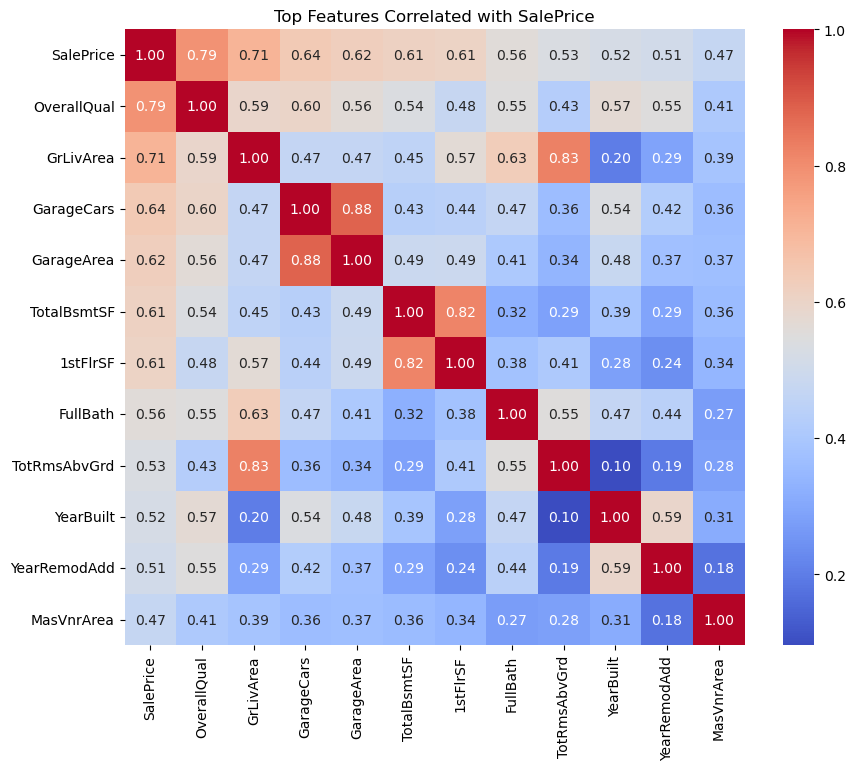

In [22]:
# Select top features correlated with SalePrice
top_features = df_train.corr(numeric_only=True)["SalePrice"].abs().sort_values(ascending=False).head(12).index

# Compute correlation matrix for those features
corr_top = df_train[top_features].corr()

plt.figure(figsize=(10,8))

sns.heatmap(corr_top,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Top Features Correlated with SalePrice")

plt.show()

## Correlation of Key Features with SalePrice

Instead of visualizing all 80 features, we focus on the variables most strongly correlated with SalePrice.

Key insights include:

- **OverallQual** shows the strongest positive correlation with SalePrice. This indicates that houses with better construction quality and materials tend to sell at significantly higher prices.
  
- **GrLivArea** (above ground living area) is also highly correlated with SalePrice. Larger homes typically command higher prices.

- **GarageCars** and **GarageArea** have strong positive relationships with SalePrice, suggesting that parking capacity and garage size add substantial value.

- **TotalBsmtSF** also correlates strongly with SalePrice, indicating that houses with larger basements tend to be more valuable.

These features are likely to be among the most important predictors when building machine learning models for house price prediction.

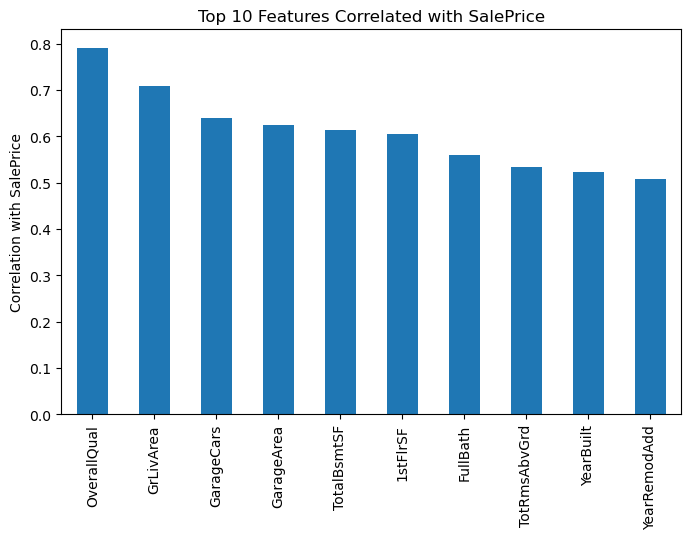

In [23]:
top_corr = df_train.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)[1:11]

plt.figure(figsize=(8,5))

top_corr.plot(kind="bar")

plt.title("Top 10 Features Correlated with SalePrice")
plt.ylabel("Correlation with SalePrice")

plt.show()

## Top Features Influencing SalePrice

The bar chart highlights the variables most strongly associated with house prices.

The most influential features include:

- Overall quality of the house
- Above-ground living area
- Garage capacity
- Basement size

These results align with expectations in real estate markets, where larger homes with higher construction quality and better amenities tend to command higher prices.

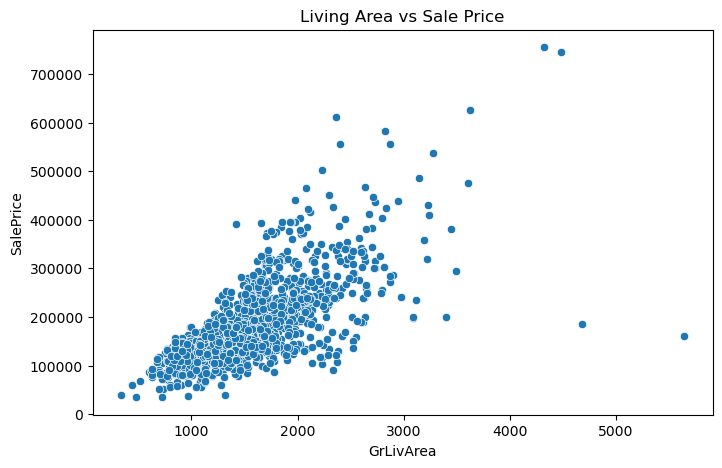

In [24]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df_train["GrLivArea"], y=df_train["SalePrice"])

plt.title("Living Area vs Sale Price")

plt.show()

## Living Area vs Sale Price

There is a strong positive relationship between **GrLivArea (above ground living area)** and **SalePrice**.

This indicates that houses with larger living areas tend to sell for higher prices.

However, a few outliers exist where very large houses have relatively low prices, which may need to be investigated further.

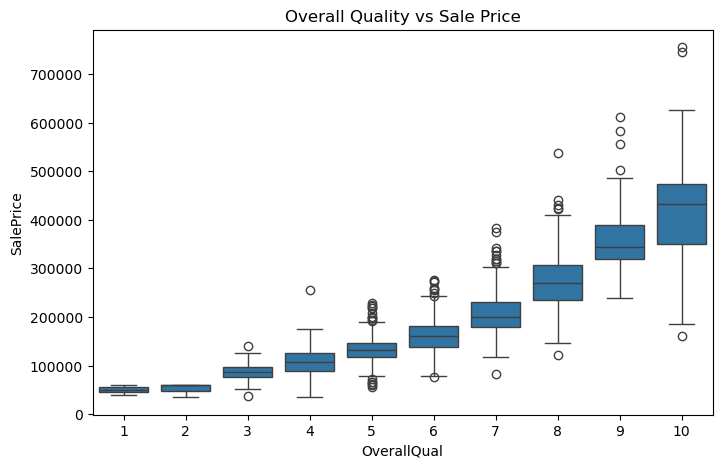

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df_train["OverallQual"], y=df_train["SalePrice"])

plt.title("Overall Quality vs Sale Price")

plt.show()

## Overall Quality vs Sale Price

The boxplot shows a strong relationship between **OverallQual** and SalePrice.

Houses with higher quality ratings tend to have significantly higher sale prices.

This suggests that construction quality is one of the most important factors influencing house prices.

## Feature Engineering

In [26]:
df_train["TotalBathrooms"] = (
    df_train["FullBath"]
    + (0.5 * df_train["HalfBath"])
    +df_train["BsmtFullBath"]
    + (0.5 * df_train["BsmtHalfBath"])
)

## TotalBathroom
Bathrooms are split across several columns in the dataset.

To simplify the model input, we create a new feature called **TotalBathrooms**.

Half bathrooms are weighted as **0.5** because they contain fewer amenities than full bathrooms.

This aggregated feature better represents the total bathroom capacity of a house.

In [27]:
df_train["HouseAge"] = df_train["YrSold"] - df_train["YearBuilt"]

A new feature called **HouseAge** is created to represent how old the house is at the time of sale.

Older houses may sell for lower prices compared to newer houses due to depreciation and maintenance requirements.

This feature can help the model better capture the effect of property age on house prices.

In [28]:
df_train["TotalArea"] = df_train["TotalBsmtSF"] + df_train["1stFlrSF"] +df_train["2ndFlrSF"]

## Total House Area

The total living space of a house is a key factor influencing its price. Homes with larger usable space generally tend to have higher market values.

To better represent the overall size of each property, we create a new feature called **TotalArea** by combining the following components:

- **Total basement area (`TotalBsmtSF`)**
- **First floor area (`1stFlrSF`)**
- **Second floor area (`2ndFlrSF`)**

By aggregating these measurements, the **TotalArea** feature provides a more comprehensive representation of the house’s total usable living space, which can help improve the predictive performance of the machine learning model.

In [29]:
# Log Transformation of SalePrice
df_train["SalePrice"] = np.log1p(df_train["SalePrice"])

The SalePrice distribution is highly skewed.

Applying a **log transformation** helps:

- Reduce skewness
- Stabilize variance
- Improve machine learning model performance

This transformation makes the target variable closer to a normal distribution.

## Feature Encoding

In [30]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalBathrooms,HouseAge,TotalArea
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,2008,WD,Normal,12.247699,3.5,5,2566
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,2007,WD,Normal,12.109016,2.5,31,2524
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,0,9,2008,WD,Normal,12.317171,3.5,7,2706
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,0,2,2006,WD,Abnorml,11.849405,2.0,91,2473
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,0,12,2008,WD,Normal,12.429220,3.5,8,3343


In [31]:
#Splitting the dataset into features or independent variables(X) & the target or dependent variable(y)
X=df_train.drop(columns=["SalePrice", "Id"])
y=df_train["SalePrice"]

The Id column is dropped because fitting it to the model will be redundant as it is unique for each observation.

In [32]:
#Using label encoder, a type of feature encoding
X_lab=X.copy()

In [33]:
for col in categorical_cols:
    le=LabelEncoder()
    X_lab[col]=le.fit_transform(X_lab[col])

In [34]:
X_lab.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,TotalBathrooms,HouseAge,TotalArea
0,60,3,65.0,8450,1,3,3,0,4,0,5,2,2,0,5,7,5,2003,2003,1,1,12,13,196.0,2,4,2,2,3,3,2,706,5,0,150,856,1,0,1,4,856,854,0,1710,1,0,2,1,3,1,2,8,6,0,1,2003.0,1,2,548,4,4,2,0,61,0,0,0,0,0,2,2008,8,4,3.5,5,2566
1,20,3,80.0,9600,1,3,3,0,2,0,24,1,2,0,2,6,8,1976,1976,1,1,8,8,0.0,3,4,1,2,3,1,0,978,5,0,284,1262,1,0,1,4,1262,0,0,1262,0,1,2,0,3,1,3,6,6,1,1,1976.0,1,2,460,4,4,2,298,0,0,0,0,0,0,5,2007,8,4,2.5,31,2524
2,60,3,68.0,11250,1,0,3,0,4,0,5,2,2,0,5,7,5,2001,2002,1,1,12,13,162.0,2,4,2,2,3,2,2,486,5,0,434,920,1,0,1,4,920,866,0,1786,1,0,2,1,3,1,2,6,6,1,1,2001.0,1,2,608,4,4,2,0,42,0,0,0,0,0,9,2008,8,4,3.5,7,2706
3,70,3,60.0,9550,1,0,3,0,0,0,6,2,2,0,5,7,5,1915,1970,1,1,13,15,0.0,3,4,0,3,1,3,0,216,5,0,540,756,1,2,1,4,961,756,0,1717,1,0,1,0,3,1,2,7,6,1,5,1998.0,2,3,642,4,4,2,0,35,272,0,0,0,0,2,2006,8,0,2.0,91,2473
4,60,3,84.0,14260,1,0,3,0,2,0,15,2,2,0,5,8,5,2000,2000,1,1,12,13,350.0,2,4,2,2,3,0,2,655,5,0,490,1145,1,0,1,4,1145,1053,0,2198,1,0,2,1,4,1,2,9,6,1,1,2000.0,1,3,836,4,4,2,192,84,0,0,0,0,0,12,2008,8,4,3.5,8,3343


In [35]:
X.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,TotalBathrooms,HouseAge,TotalArea
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,2008,WD,Normal,3.5,5,2566
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,2007,WD,Normal,2.5,31,2524
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,0,9,2008,WD,Normal,3.5,7,2706
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,0,2,2006,WD,Abnorml,2.0,91,2473
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,0,12,2008,WD,Normal,3.5,8,3343


In [36]:
#One-Hot Encoder
X_oh=X.copy()

In [37]:
X_oh=pd.get_dummies(X_oh, columns=categorical_cols, dtype="int")

In [38]:
X_oh.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,TotalBathrooms,HouseAge,TotalArea,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_AllPub,Utilities_NoSeWa,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Gtl,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Artery,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Artery,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Flat,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_ClyTile,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsbShng,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsbShng,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,ExterQual_Ex,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,ExterCond_Ex,ExterCond_Fa,ExterCond_Gd,ExterCond_Po,ExterCond_TA,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtQual_Ex,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_TA,BsmtCond_Fa,BsmtCond_Gd,BsmtCond_Po,BsmtCond_TA,BsmtExposure_Av,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtFinType1_ALQ,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_ALQ,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_Floor,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,HeatingQC_Ex,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Po,HeatingQC_TA,CentralAir_N,CentralAir_Y,Electrical_FuseA,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageFinish_Fin,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Ex,GarageQual_Fa,GarageQual_Gd,GarageQual_Po,GarageQual_TA,GarageCond_Ex,GarageCond_Fa,GarageCond_Gd,GarageCond_Po,GarageCond_TA,PavedDrive_N,PavedDrive_P,PavedDrive_Y,SaleType_COD,Sal

## Feature Scaling

In [39]:
X_lab.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,TotalBathrooms,HouseAge,TotalArea
0,60,3,65.0,8450,1,3,3,0,4,0,5,2,2,0,5,7,5,2003,2003,1,1,12,13,196.0,2,4,2,2,3,3,2,706,5,0,150,856,1,0,1,4,856,854,0,1710,1,0,2,1,3,1,2,8,6,0,1,2003.0,1,2,548,4,4,2,0,61,0,0,0,0,0,2,2008,8,4,3.5,5,2566
1,20,3,80.0,9600,1,3,3,0,2,0,24,1,2,0,2,6,8,1976,1976,1,1,8,8,0.0,3,4,1,2,3,1,0,978,5,0,284,1262,1,0,1,4,1262,0,0,1262,0,1,2,0,3,1,3,6,6,1,1,1976.0,1,2,460,4,4,2,298,0,0,0,0,0,0,5,2007,8,4,2.5,31,2524
2,60,3,68.0,11250,1,0,3,0,4,0,5,2,2,0,5,7,5,2001,2002,1,1,12,13,162.0,2,4,2,2,3,2,2,486,5,0,434,920,1,0,1,4,920,866,0,1786,1,0,2,1,3,1,2,6,6,1,1,2001.0,1,2,608,4,4,2,0,42,0,0,0,0,0,9,2008,8,4,3.5,7,2706
3,70,3,60.0,9550,1,0,3,0,0,0,6,2,2,0,5,7,5,1915,1970,1,1,13,15,0.0,3,4,0,3,1,3,0,216,5,0,540,756,1,2,1,4,961,756,0,1717,1,0,1,0,3,1,2,7,6,1,5,1998.0,2,3,642,4,4,2,0,35,272,0,0,0,0,2,2006,8,0,2.0,91,2473
4,60,3,84.0,14260,1,0,3,0,2,0,15,2,2,0,5,8,5,2000,2000,1,1,12,13,350.0,2,4,2,2,3,0,2,655,5,0,490,1145,1,0,1,4,1145,1053,0,2198,1,0,2,1,4,1,2,9,6,1,1,2000.0,1,3,836,4,4,2,192,84,0,0,0,0,0,12,2008,8,4,3.5,8,3343


Note that label encoder is used as the feature encoder here as it does not introduce more columns which can cause multicollinearity like one-hot encoder. Also, only the input features are scaled not the target variable.

In [40]:
#StandardScaler is used to bring the features (X) to normal distribution (mean=0, Standard Deviation=1) level.
scaler=StandardScaler()
scaledX=scaler.fit_transform(X_lab)

In [41]:
scaledX

array([[ 7.33749635e-02, -4.55319398e-02, -2.20875089e-01, ...,
         1.64225584e+00, -1.04325937e+00, -1.27658638e-03],
       [-8.72562756e-01, -4.55319398e-02,  4.60319735e-01, ...,
         3.68580659e-01, -1.83465064e-01, -5.24067478e-02],
       [ 7.33749635e-02, -4.55319398e-02, -8.46361241e-02, ...,
         1.64225584e+00, -9.77121342e-01,  1.69157285e-01],
       ...,
       [ 3.09859393e-01, -4.55319398e-02, -1.75462101e-01, ...,
        -2.68256929e-01,  1.07315738e+00,  1.12602173e+00],
       [-8.72562756e-01, -4.55319398e-02, -8.46361241e-02, ...,
        -2.68256929e-01,  7.75536272e-01, -5.00404352e-01],
       [-8.72562756e-01, -4.55319398e-02,  2.33254794e-01, ...,
         3.68580659e-01,  2.13363075e-01, -6.70153653e-02]],
      shape=(1460, 76))

## Train-Test Split

In [42]:
X_train,X_test,y_train,y_test=train_test_split(scaledX, y, test_size=0.2, random_state=42) 

The given train dataset is splitted using the ratio 80:20 for the training and testing dataset respectively. AS train_test split randomly we set the random state to 42 ensures we save the randomization.

In [43]:
X_train.shape

(1168, 76)

In [44]:
X_test.shape

(292, 76)

## Building Model

In [45]:
#Linear regression is used as the base model because it assumes linear relationship between X and y
lreg=LinearRegression()
lreg.fit(X_train, y_train) #fitting the model to the training set

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
lreg_pred=lreg.predict(X_test)
lreg_pred

array([11.94626067, 12.69448468, 11.67240713, 12.0501009 , 12.67118176,
       11.39950978, 12.40092623, 11.92817513, 11.42436712, 11.87620987,
       11.92650433, 11.71724026, 11.45691726, 12.20363202, 12.02324013,
       11.83376617, 12.22370522, 11.75010576, 11.65173493, 12.29274091,
       11.9213918 , 12.25095945, 12.12252391, 11.83360548, 12.2605608 ,
       11.92655694, 12.22334163, 11.4655076 , 12.05843873, 12.17318376,
       11.95028298, 12.43068953, 11.99628068, 11.61068301, 12.4865373 ,
       11.88522893, 11.77697268, 12.24826758, 12.65371734, 11.50859415,
       11.76772814, 12.40024865, 11.6373195 , 12.65855766, 11.7498226 ,
       11.71904808, 11.54889064, 11.80974793, 12.90945983, 11.73301579,
       11.6821734 , 12.24303011, 11.65431004, 12.76635593, 11.88538366,
       12.35392458, 12.30728848, 11.9936472 , 11.79802226, 11.64413309,
       11.09320263, 11.97850524, 12.62885524, 12.41616333, 12.62088978,
       12.32720952, 11.59323307, 12.69661457, 11.60868941, 11.97

In [47]:
y_test

892     11.947956
1105    12.691584
413     11.652696
522     11.976666
1036    12.661917
          ...    
479     11.401681
1361    12.468441
802     12.149508
651     11.589896
722     11.732069
Name: SalePrice, Length: 292, dtype: float64

## Evaluation Metric

In [48]:
r2_score(y_test, lreg_pred)

0.8742570804722902

In [49]:
mean_absolute_error(y_test, lreg_pred)#MAE

0.10611733110042107

In [50]:
mean_squared_error(y_test, lreg_pred) #MSE

0.02346501052113693

In [51]:
lreg_pred_actual = np.expm1(lreg_pred)
y_test_actual = np.expm1(y_test)

np.sqrt(mean_squared_error(y_test_actual, lreg_pred_actual)) #RMSE

np.float64(27575.10412332079)

In [52]:
#Decision Tree Regression Model
tree_reg=DecisionTreeRegressor()
tree_reg.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [53]:
tree_reg_pred=tree_reg.predict(X_test)
tree_reg_pred

array([11.66993776, 12.92391488, 11.54249398, 12.08391066, 12.57763965,
       11.30221678, 12.29911207, 11.90834697, 11.28979441, 11.68688718,
       12.15452142, 11.77529742, 11.54249398, 12.3327097 , 12.13619188,
       11.8277435 , 12.05380103, 11.88380603, 11.72804491, 12.30592251,
       12.01067193, 12.20557752, 12.12811651, 11.69525536, 12.22588017,
       12.12811651, 12.36308067, 11.54249398, 12.06105265, 12.1428719 ,
       11.90497431, 12.16525586, 12.10071769, 11.71994776, 12.45410781,
       11.90497431, 11.84223641, 12.17045065, 12.57763965, 11.60824474,
       11.56647571, 12.35879802, 11.67420212, 13.27582925, 11.87583792,
       11.84940484, 11.50792297, 11.73607702, 13.0086615 , 11.81303746,
       11.80932691, 12.07254697, 11.4563657 , 12.83468397, 11.8706069 ,
       12.46997803, 12.0435596 , 11.88380603, 11.95118685, 11.60368896,
       11.41862577, 11.00211651, 12.74444729, 12.49087934, 12.8413285 ,
       12.38422302, 11.77529742, 12.67294952, 11.58989577, 12.00

In [54]:
r2_score(y_test, tree_reg_pred)

0.7475721390379476

In [55]:
mean_absolute_error(y_test, tree_reg_pred)#MAE

0.1459492936946099

In [56]:
mean_squared_error(y_test, tree_reg_pred) #MSE

0.04710581268154311

In [57]:
tree_reg_pred_actual = np.expm1(tree_reg_pred)
y_test_actual = np.expm1(y_test)

np.sqrt(mean_squared_error(y_test_actual, tree_reg_pred_actual)) #RMSE

np.float64(43491.799583212254)

In [58]:
#Random Forest Regression Model
forest_reg=RandomForestRegressor(random_state=16)
forest_reg.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [59]:
forest_reg_pred=forest_reg.predict(X_test)
forest_reg_pred

array([11.85023869, 12.70649885, 11.61746785, 11.95177101, 12.63319131,
       11.33273806, 12.19733975, 11.91822676, 11.35213956, 11.80347525,
       11.98377478, 11.70088959, 11.5944364 , 12.28937133, 12.0828487 ,
       11.7798492 , 12.19687058, 11.80807299, 11.60525083, 12.24851953,
       12.02603633, 12.19210938, 12.10919164, 11.74648567, 12.20489138,
       12.04319774, 12.12027742, 11.6015513 , 12.08967172, 12.21652353,
       11.70273398, 12.41863989, 12.13624238, 11.63863257, 12.43405775,
       11.89560948, 11.81574968, 12.22246991, 12.60307472, 11.49897153,
       11.63635347, 12.37415479, 11.67342817, 12.87713   , 11.79778031,
       11.8585433 , 11.63694885, 11.76929205, 12.89831484, 11.84708959,
       11.73208886, 12.15883836, 11.52972859, 12.68199545, 11.85162973,
       12.47483266, 12.16318674, 11.92909357, 11.93188609, 11.6001083 ,
       11.20966288, 11.90422085, 12.64643568, 12.46017644, 12.58234334,
       12.25188879, 11.63914805, 12.63422394, 11.63727166, 12.01

In [60]:
r2_score(y_test, forest_reg_pred)

0.8859922631281809

In [61]:
mean_absolute_error(y_test, forest_reg_pred)#MAE


0.09792325715897368

In [62]:
mean_squared_error(y_test, forest_reg_pred) #MSE

0.021275096484448294

In [63]:
forest_reg_pred_actual = np.expm1(forest_reg_pred)
y_test_actual = np.expm1(y_test)

np.sqrt(mean_squared_error(y_test_actual, forest_reg_pred_actual)) #RMSE

np.float64(29566.688288337242)

## Comparison of Evaluation Metrics of Models

In [64]:
# Storing predictions
models = {
    "Linear Regression": lreg_pred,
    "Decision Tree": tree_reg_pred,
    "Random Forest": forest_reg_pred
}

results = []

for model_name, pred in models.items():
    
    # Convert predictions and actual values back to original price scale
    pred_actual = np.expm1(pred)
    y_test_actual = np.expm1(y_test)
    
    r2 = r2_score(y_test_actual, pred_actual)
    mae = mean_absolute_error(y_test_actual, pred_actual)
    mse = mean_squared_error(y_test_actual, pred_actual)
    rmse = np.sqrt(mse)
    
    results.append([model_name, r2, mae, mse, rmse])

results_df = pd.DataFrame(results, columns=["Model", "R2 Score", "MAE", "MSE", "RMSE"])

results_df


,Model,R2 Score,MAE,MSE,RMSE
0,Linear Regression,0.900866,18127.306311,7.603864e+08,27575.104123
1,Decision Tree,0.753396,25828.500000,1.891537e+09,43491.799583
2,Random Forest,0.886030,17334.206086,8.741891e+08,29566.688288


### Insight on Model Evaluation Metrics

This step evaluates the performance of all trained regression models using key metrics:

| Metric | Meaning |
|--------|---------|
| **R² Score** | Measures how well the model explains the variance in the target variable |
| **MAE** | Average absolute difference between predicted and actual values |
| **MSE** | Average squared error between predicted and actual values |
| **RMSE** | Square root of MSE, interpretable in the same unit as the target variable |

**Key Insight:**

- **Higher R²** → better model fit  
- **Lower MAE / MSE / RMSE** → better prediction accuracy  

The **best regression model** is typically the one with:

- The **highest R² score**  
- The **lowest RMSE**  

In this case, the **Linear Regression model** has the **highest R²** and the **lowest RMSE**, indicating it is the **best-performing model** based on these evaluation metrics.

## Cross-Validation

In [65]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Linear Regression": lreg,
    "Decision Tree": tree_reg,
    "Random Forest": forest_reg
}

cv_results = {}

for name, model in models.items():
    
    scores = cross_val_score(
        model,
        scaledX,
        y,
        cv=kfold,
        scoring="r2"
    )
    
    cv_results[name] = scores.mean()

cv_results

{'Linear Regression': np.float64(0.8235749601874833),
 'Decision Tree': np.float64(0.7120655746800798),
 'Random Forest': np.float64(0.8686316124397677)}

### Insight on 5-Fold Cross Validation

This step performs **5-Fold Cross Validation** to evaluate the model's performance more reliably.

**How it works internally:**

1. The dataset is divided into **5 equal parts (folds)**.
2. The model **trains on 4 folds** and **tests on the remaining 1 fold**.
3. This process **repeats 5 times**, with each fold serving as the test set once.
4. The performance scores from all folds are then **averaged** to produce the final Cross Validation score.

**Benefits of K-Fold Cross Validation:**

- Helps **reduce overfitting**
- Provides a **more reliable estimate of model performance**
- Allows the model to **use more data for training**

The final output represents the **average R² score across the 5 folds**.

**Conclusion:**

Three models were evaluated using both a train–test split and cross-validation.

Although Linear Regression achieved the highest R² score on the test set (0.90), Random Forest achieved the best average performance during cross-validation (0.87).

Cross-validation provides a more reliable estimate of model performance because it evaluates the model across multiple training and testing splits.

Therefore, **Random Forest is considered the most robust model for this prediction task**.

## Hyperparameter Tuning of the Best Model (Random Forest)

In [66]:
# since the random forest id the best model for this task we will perform hyperparameter tuning for it

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf_model = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf_model = grid_search.best_estimator_

grid_search.best_params_

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}

### Insight on GridSearchCV and Hyperparameter Tuning

**GridSearchCV** automatically tests multiple combinations of hyperparameters to determine the best configuration for a model.

For example, it may evaluate combinations such as:

| n_estimators | max_depth | min_samples_split |
|--------------|-----------|-------------------|
| 100          | None      | 2                 |
| 100          | 10        | 5                 |
| 200          | 20        | 10                |

Each parameter combination is evaluated using **cross-validation**, which means the model is trained and validated on multiple data splits to ensure reliable performance.

**Key Insight:**

GridSearchCV selects the **best-performing combination of parameters** based on the evaluation metric. This process helps improve the model by:

- Increasing **accuracy**
- Improving **generalization** to unseen data
- Enhancing **model stability**

As a result, hyperparameter tuning helps produce a **more reliable and better-performing machine learning model**.

In [67]:
# Evaluate the tuned Random Forest model

# Generate predictions (log scale)
best_pred_log = best_rf_model.predict(X_test)

# Convert both predictions and actual values back to original scale
y_test_actual = np.expm1(y_test)
best_pred_actual = np.expm1(best_pred_log)

# Calculate evaluation metrics
r2 = r2_score(y_test_actual, best_pred_actual)
mae = mean_absolute_error(y_test_actual, best_pred_actual)
mse = mean_squared_error(y_test_actual, best_pred_actual)
rmse = np.sqrt(mse)

# Display results
print(f"R² Score: {r2:.6f}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

R² Score: 0.887472
MAE: 17111.37
MSE: 863126748.38
RMSE: 29379.02


### Insight

After comparing the model performance before and after hyperparameter tuning, we observe the following results:

| Model                         | R² Score | RMSE |
|------------------------------|----------|----------------|
| Random Forest (Before Tuning) | 0.886030 | 29566.68 |
| Random Forest (After Tuning)  | 0.887472 | 29379.02 |

**Interpretation:**

- The **R² score increased** from **0.886030** to **0.887472**, indicating that the tuned model explains more variance in the data.
- The **RMSE decreased** from **29566.68** to **29379.02**, meaning the prediction error has reduced.

**Conclusion:**

Since **R² increased** and **RMSE decreased**, the **hyperparameter tuning improved the performance of the Random Forest model**.

         Feature    Importance
15   OverallQual  4.095058e-01
75     TotalArea  3.469985e-01
57    GarageCars  1.511808e-02
43     GrLivArea  1.305971e-02
58    GarageArea  1.234063e-02
..           ...           ...
65     3SsnPorch  9.810195e-05
42  LowQualFinSF  9.383281e-05
12    Condition2  6.142973e-05
4         Street  8.060002e-06
7      Utilities  6.794223e-07

[76 rows x 2 columns]


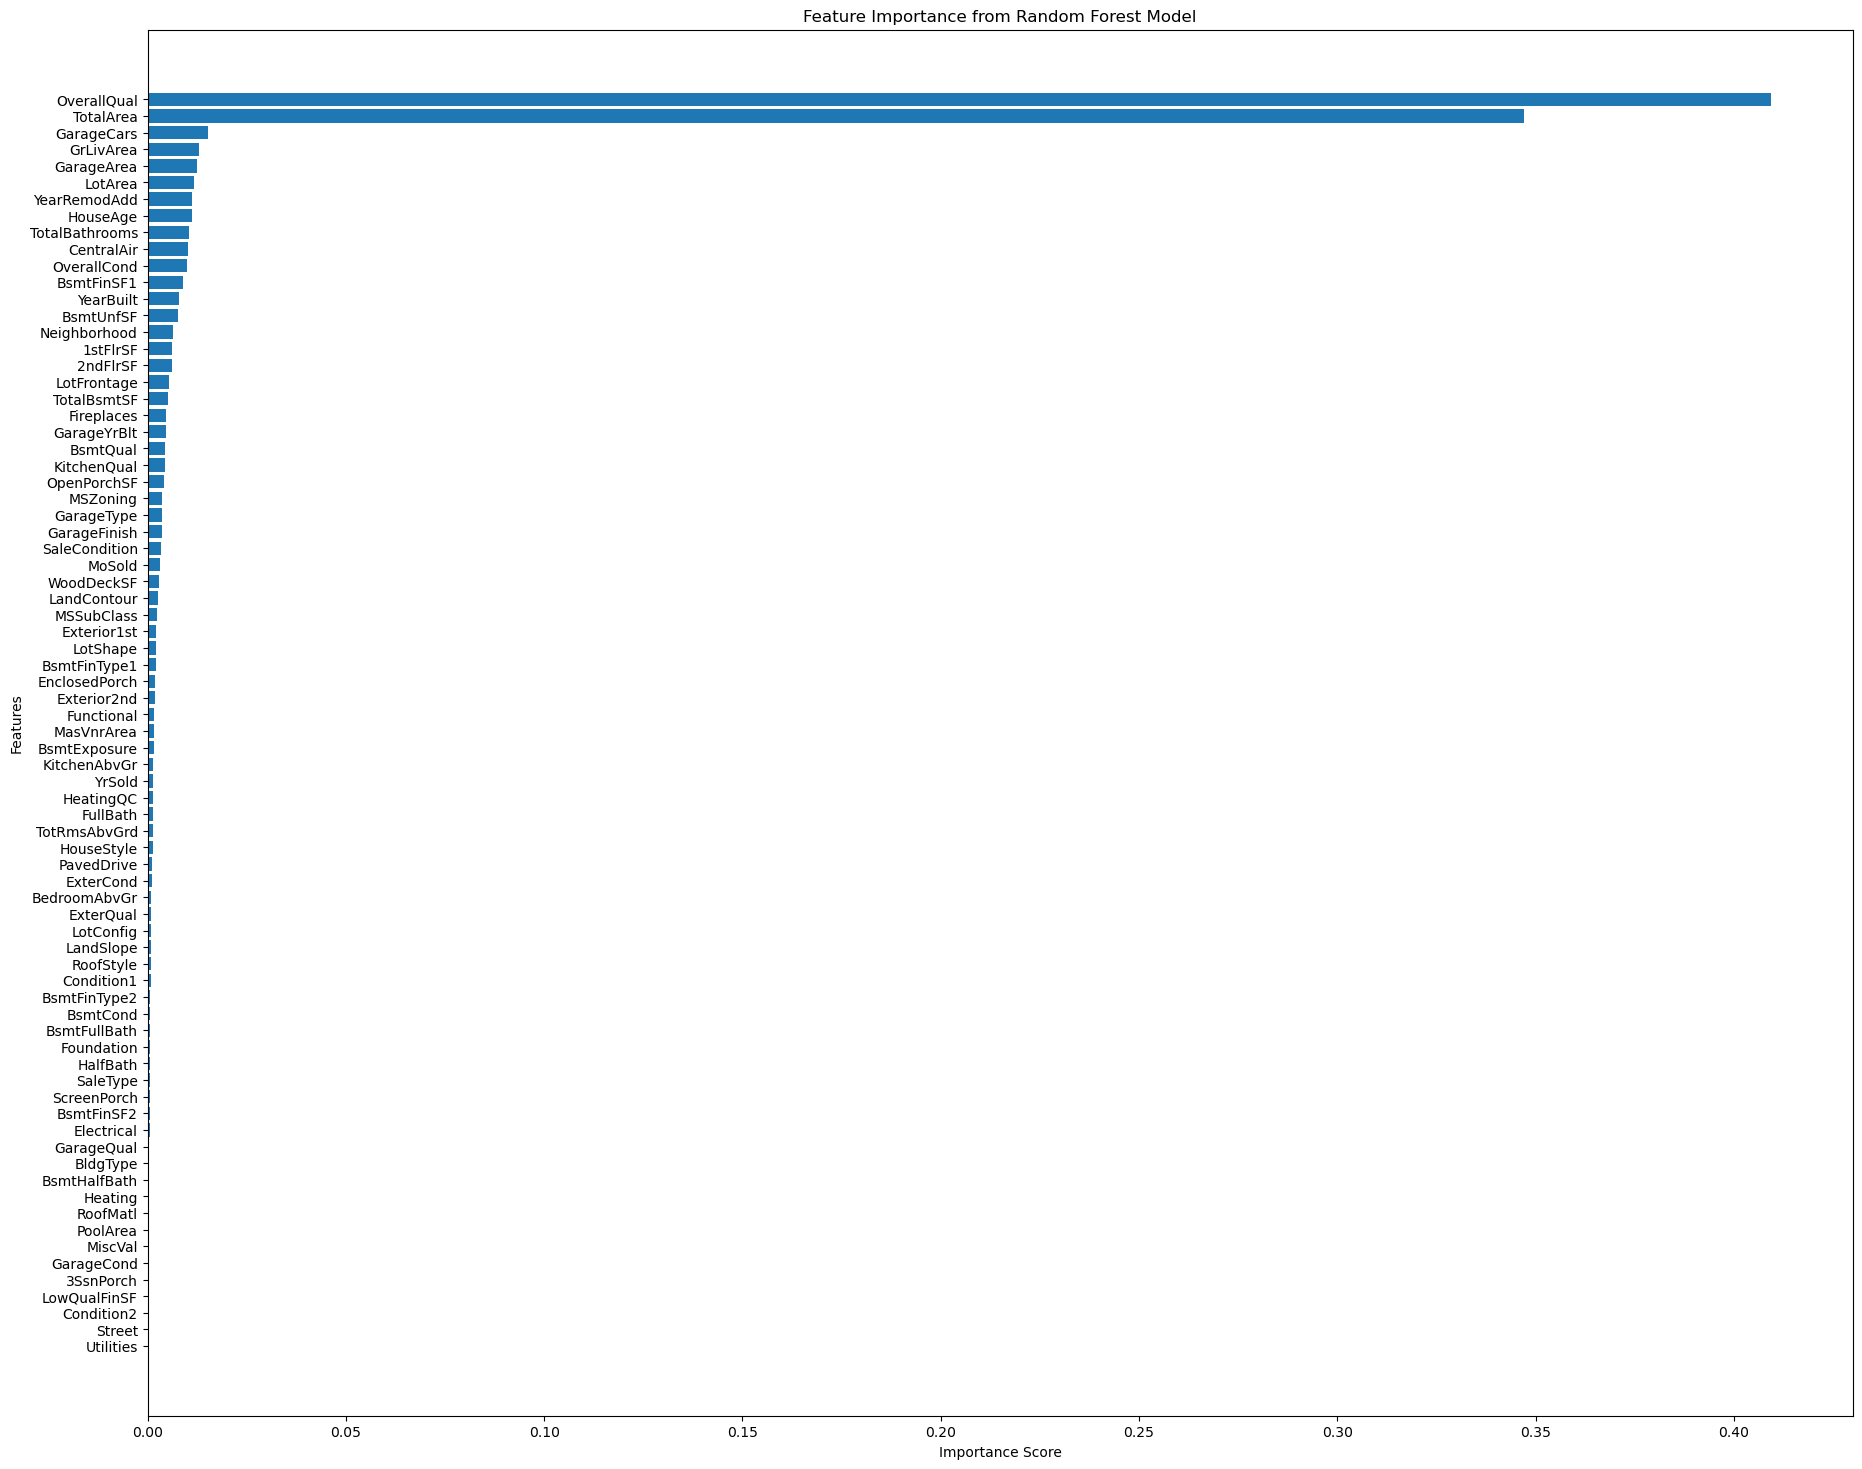

In [68]:
# Getting feature importance from the trained Random Forest model


# Extracting feature importance
importance = forest_reg.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

# Sort values
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

# Display top features
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(22,18))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance from Random Forest Model")
plt.gca().invert_yaxis()
plt.show()

## Feature Importance Analysis

After training the Random Forest model, feature importance was analyzed to understand which variables contribute most to predicting house prices.

The feature importance plot shows that **OverallQual** and **TotalArea** have the most significant influence on house price prediction. Both features display noticeably longer bars compared to other variables, indicating their strong predictive power.

- **OverallQual** represents the overall material and finish quality of the house. Houses with higher construction quality naturally command higher prices in the market.
- **TotalArea**, which aggregates the basement, first floor, and second floor areas, captures the overall usable living space of the house. Larger homes typically have higher property values.

Following these top predictors are:

- **GarageCars**, which indicates the garage capacity. Homes with larger garage space tend to be more desirable.
- **GrLivArea**, representing above-ground living area, which further reflects the size and comfort level of the house.

Overall, the feature importance analysis confirms that **house quality and total living space are the dominant factors influencing house prices**, while additional amenities like garage capacity and living area also contribute significantly to property valuation.

## Deployment

In [70]:
# ================================
# Full Pipeline for Deployment
# ================================

import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import pickle

# ------------------------
# 1. Load your data
# ------------------------
# X = your feature dataframe
# y = your target variable
# Example:
# X = df.drop("rent", axis=1)
# y = df["rent"]

# ------------------------
# 2. Custom LabelEncoder for multiple columns
# ------------------------
class MultiColumnLabelEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None):
        self.columns = columns  # list of columns to encode
        self.encoders = {}
    
    def fit(self, X, y=None):
        for col in self.columns:
            le = LabelEncoder()
            le.fit(X[col])
            self.encoders[col] = le
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        for col, le in self.encoders.items():
            X_copy[col] = le.transform(X_copy[col])
        return X_copy

# ------------------------
# 3. Identify numeric & categorical columns
# ------------------------
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

# ------------------------
# 4. Define transformers
# ------------------------
numeric_transformer = StandardScaler()
categorical_transformer = MultiColumnLabelEncoder(columns=categorical_cols)

# ------------------------
# 5. Combine transformers into a preprocessor
# ------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# ------------------------
# 6. Define the best model
# ------------------------
best_model = RandomForestRegressor(random_state=16)

# ------------------------
# 7. Create the pipeline
# ------------------------
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", best_model)
])

# ------------------------
# 8. Fit the pipeline on the ENTIRE dataset
# ------------------------
pipeline.fit(X, y)

# ------------------------
# 9. Save the pipeline to a file for deployment
# ------------------------
with open("house_rent_model.pkl", "wb") as file:
    pickle.dump(pipeline, file)

print("Pipeline saved successfully! Ready for Streamlit deployment.")

Pipeline saved successfully! Ready for Streamlit deployment.


In [72]:
X.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPor